Dataset shape: (4238, 16)
Missing values fixed!
Preprocessing done!


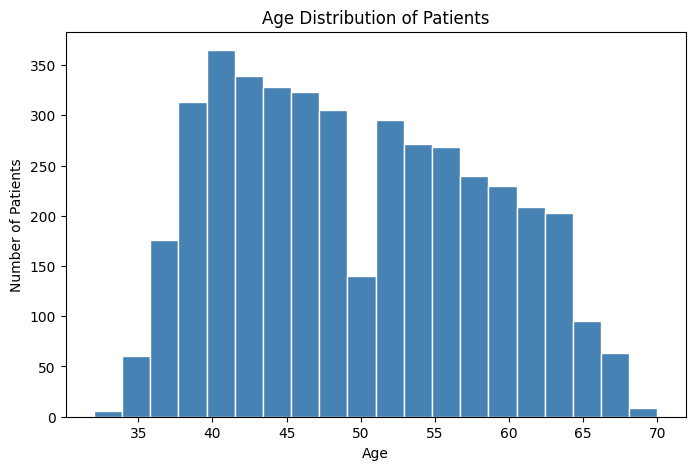

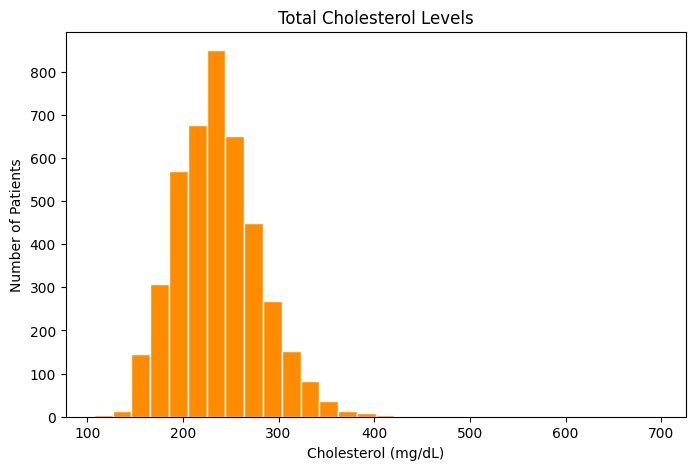

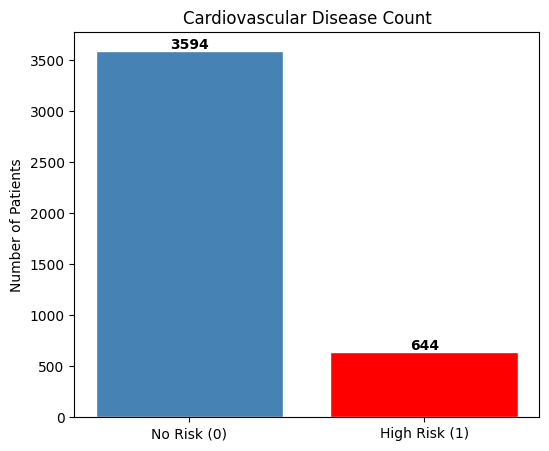

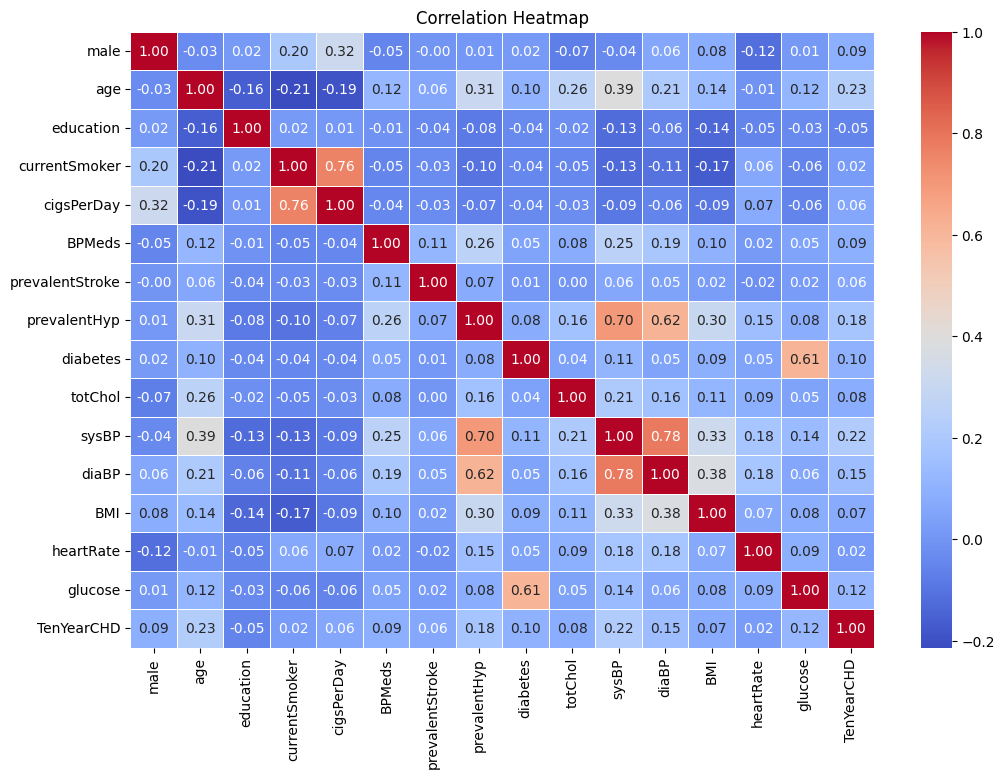

All models trained!
Model Accuracy Comparison
-----------------------------------
Logistic Regression : 85.73%
Decision Tree       : 84.67%
Random Forest       : 85.02%
KNN                 : 83.25%


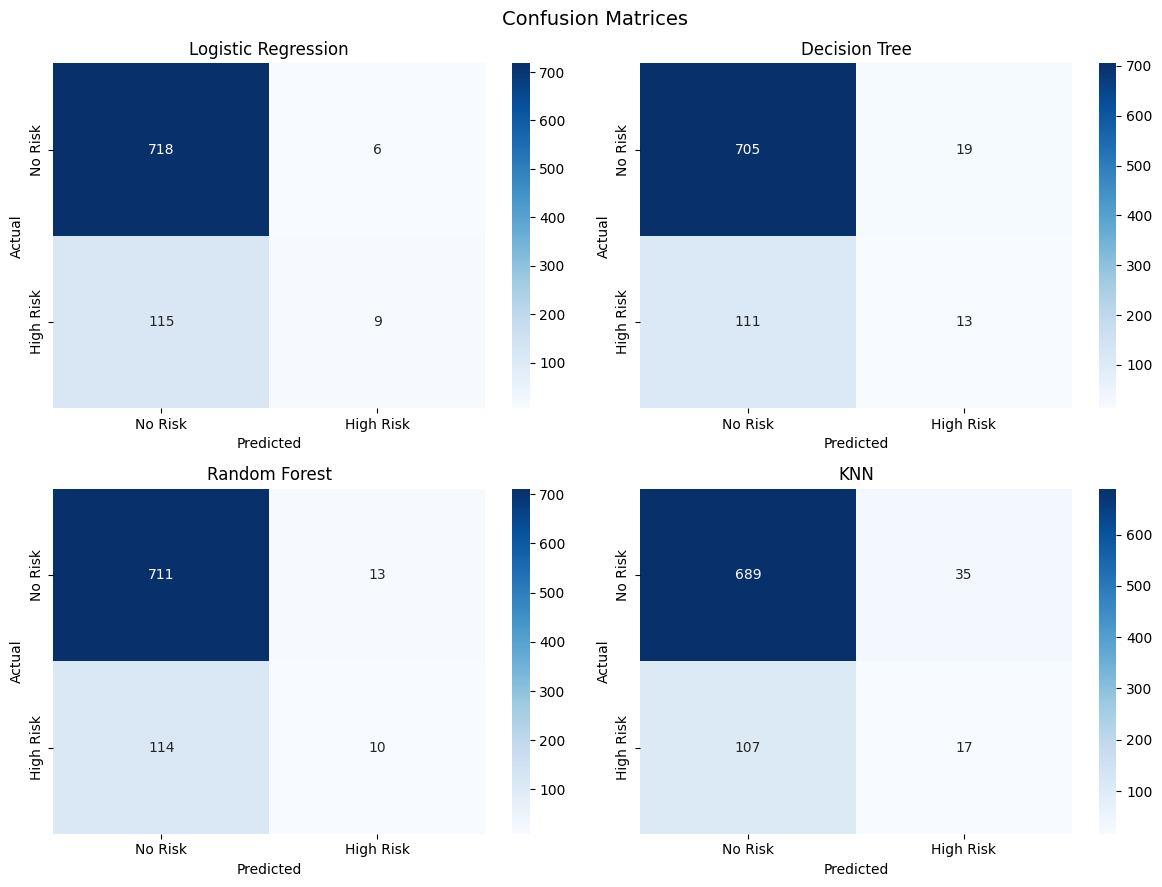


=== Logistic Regression ===
              precision    recall  f1-score   support

     No Risk       0.86      0.99      0.92       724
   High Risk       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848


=== Decision Tree ===
              precision    recall  f1-score   support

     No Risk       0.86      0.97      0.92       724
   High Risk       0.41      0.10      0.17       124

    accuracy                           0.85       848
   macro avg       0.64      0.54      0.54       848
weighted avg       0.80      0.85      0.81       848


=== Random Forest ===
              precision    recall  f1-score   support

     No Risk       0.86      0.98      0.92       724
   High Risk       0.43      0.08      0.14       124

    accuracy                           0.85       848
   macro avg       0.65      0.53      0.53       848

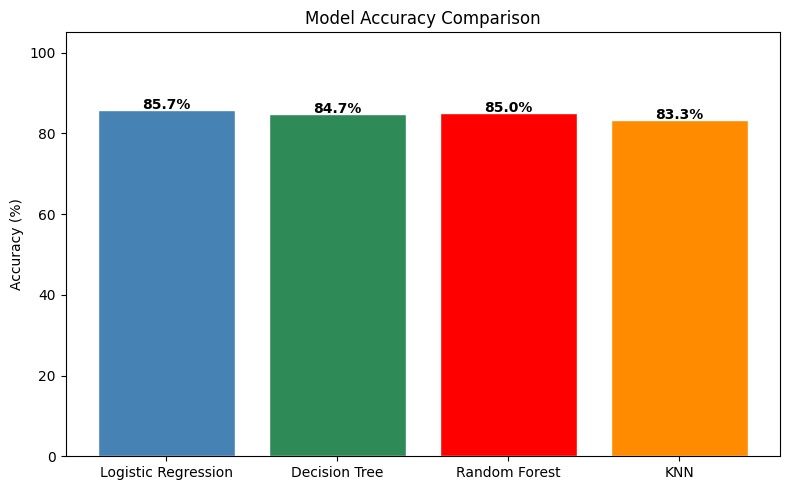

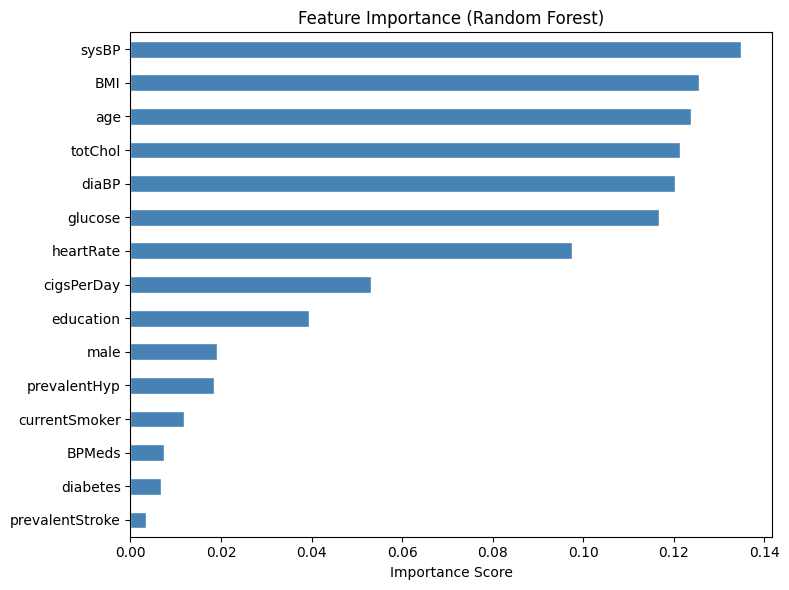


Patient: Male, 55 yrs, smoker, hypertension, high cholesterol
--------------------------------------------------
Result: LOW RISK
Risk Probability: 38.5%


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('framingham.csv')
print('Dataset shape:', df.shape)

# Fix missing values
df.fillna(df.median(), inplace=True)
print('Missing values fixed!')

# Separate features and target
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Preprocessing done!')

# Chart 1: Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

# Chart 2: Cholesterol Levels
plt.figure(figsize=(8,5))
plt.hist(df['totChol'], bins=30, color='darkorange', edgecolor='white')
plt.title('Total Cholesterol Levels')
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Number of Patients')
plt.show()

# Chart 3: Disease Count
counts = df['TenYearCHD'].value_counts()
plt.figure(figsize=(6,5))
bars = plt.bar(['No Risk (0)', 'High Risk (1)'], counts.values, color=['steelblue','red'], edgecolor='white')
for i, v in enumerate(counts.values):
    plt.text(i, v+20, str(v), ha='center', fontweight='bold')
plt.title('Cardiovascular Disease Count')
plt.ylabel('Number of Patients')
plt.show()

# Chart 4: Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Train Models
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_predictions = knn_model.predict(X_test_scaled)

print('All models trained!')

# Accuracy
lr_acc  = accuracy_score(y_test, lr_predictions)
dt_acc  = accuracy_score(y_test, dt_predictions)
rf_acc  = accuracy_score(y_test, rf_predictions)
knn_acc = accuracy_score(y_test, knn_predictions)

print('Model Accuracy Comparison')
print('-' * 35)
print(f'Logistic Regression : {lr_acc  * 100:.2f}%')
print(f'Decision Tree       : {dt_acc  * 100:.2f}%')
print(f'Random Forest       : {rf_acc  * 100:.2f}%')
print(f'KNN                 : {knn_acc * 100:.2f}%')

# Confusion Matrices
models      = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN']
predictions = [lr_predictions, dt_predictions, rf_predictions, knn_predictions]

fig, axes = plt.subplots(2, 2, figsize=(12,9))
axes = axes.flatten()
for i, (name, preds) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Risk','High Risk'],
                yticklabels=['No Risk','High Risk'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# Classification Reports
for name, preds in zip(models, predictions):
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['No Risk','High Risk']))

# Accuracy Bar Chart
accuracies = [lr_acc, dt_acc, rf_acc, knn_acc]
plt.figure(figsize=(8,5))
bars = plt.bar(models, [a*100 for a in accuracies],
               color=['steelblue','seagreen','red','darkorange'], edgecolor='white')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{acc*100:.1f}%', ha='center', fontweight='bold')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# Feature Importance
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=True)
plt.figure(figsize=(8,6))
feature_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Predict new patient
new_patient = [[1, 55, 2, 1, 15, 0, 0, 1, 0, 260, 150, 90, 28.0, 80, 130]]
new_patient_df     = pd.DataFrame(new_patient, columns=X.columns)
new_patient_scaled = scaler.transform(new_patient_df)
prediction  = lr_model.predict(new_patient_scaled)
probability = lr_model.predict_proba(new_patient_scaled)[0][1]
print('\nPatient: Male, 55 yrs, smoker, hypertension, high cholesterol')
print('-' * 50)
print('Result:', 'HIGH RISK' if prediction[0]==1 else 'LOW RISK')
print(f'Risk Probability: {probability*100:.1f}%')